Trees

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay

In [35]:
md= pd.read_csv('/Users/juliannahoitt/Desktop/MATH6243/FinalProj/Biodiversity-Predictors/data/processed/marine_data_cleaned.csv')
print(md.head())

   STUDY_ID  LATITUDE  LONGITUDE  species_richness  total_abundance  \
0       164  37.81020 -122.32300                13            126.0   
1       245  50.85045    3.61936                 9             50.0   
2       245  50.88528    3.69284                 6             49.0   
3       245  50.91131    3.41330                15           1106.0   
4       245  50.91145    3.41317                15            420.0   

   mean_depth  n_samples  n_years  year_start  year_end  ... precip_proxy  \
0    1.000000          3        2        2000      2001  ...  1463.318708   
1   -6.267057          6        2        2009      2010  ...  1133.244839   
2   -6.267057          3        2        2009      2010  ...  1311.765920   
3   -6.267057         15        2        2007      2008  ...  1330.386822   
4   -6.267057         15        2        2007      2008  ...  1041.224731   

   log_area sampling_intensity  depth_category  coastal_proxy  temp_squared  \
0  2.944439                1.5 

## features

In [11]:
# Main feature set — no log_area (it's in the denominator of target variable)
features_density = [
    'mean_depth',
    'abs_latitude',
    'dist_from_equator_km',
    'temp_proxy',
    'temp_range_proxy',
    'precip_proxy',
    'sampling_intensity',
    'coastal_proxy',
    'temp_squared',
    'temp_x_precip',
    'latitude_squared',
    'productivity_proxy'
]
 
# Robustness check — ecological variables only, no sampling_intensity
features_no_sampling = [
    'mean_depth',
    'abs_latitude',
    'dist_from_equator_km',
    'temp_proxy',
    'temp_range_proxy',
    'precip_proxy',
    'coastal_proxy',
    'temp_squared',
    'temp_x_precip',
    'latitude_squared',
    'productivity_proxy'
]


Target Variable + Feature Matrices + Train/Test Splits


In [12]:
# Check area values before dividing
print(md['AREA_SQ_KM'].describe())
print("Zero or missing areas:", (md['AREA_SQ_KM'] <= 0).sum())
print("NaN areas:", md['AREA_SQ_KM'].isna().sum())


count    1619.000000
mean      184.861025
std        91.437266
min         3.000000
25%        83.000000
50%       216.000000
75%       236.000000
max       322.000000
Name: AREA_SQ_KM, dtype: float64
Zero or missing areas: 0
NaN areas: 0


In [13]:
# Create species density target
md['species_density'] = md['species_richness'] / md['AREA_SQ_KM']


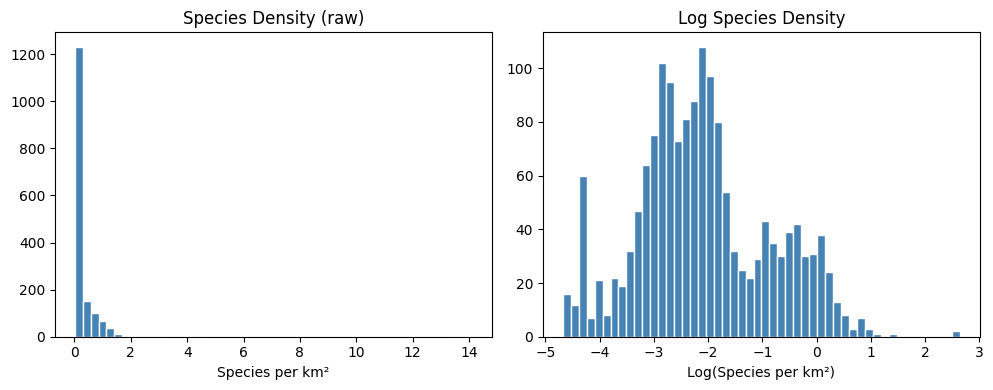

In [ ]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(md['species_density'], bins=50, color='steelblue', edgecolor='white')
plt.title('Species Density (raw)')
plt.xlabel('Species per km²')

plt.subplot(1, 2, 2)
plt.hist(np.log(md['species_density']), bins=50, color='steelblue', edgecolor='white')
plt.title('Log Species Density')
plt.xlabel('Log(Species per km²)')
plt.tight_layout()
plt.savefig('distribution_comparison_density.png', dpi=150, bbox_inches='tight')
plt.show()


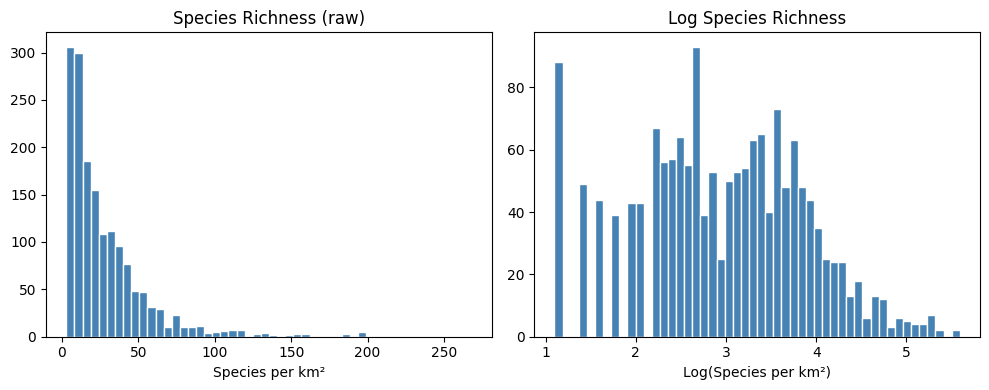

In [ ]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(md['species_richness'], bins=50, color='steelblue', edgecolor='white')
plt.title('Species Richness (raw)')
plt.xlabel('Species per km²')

plt.subplot(1, 2, 2)
plt.hist(np.log(md['species_richness']), bins=50, color='steelblue', edgecolor='white')
plt.title('Log Species Richness')
plt.xlabel('Log(Species per km²)')
plt.tight_layout()
plt.savefig('distribution_comparison_richness.png', dpi=150, bbox_inches='tight')
plt.show()


In [16]:
# Log transform of density chosen — more symmetric distribution
y_density = np.log(md['species_density']).to_numpy()
print("Target range:", y_density.min().round(3), "to", y_density.max().round(3))
print("Target mean:", y_density.mean().round(3))

Target range: -4.676 to 2.647
Target mean: -2.094


In [17]:
# Feature matrices
X_main = md[features_density].to_numpy()
X_nosamp = md[features_no_sampling].to_numpy()


In [18]:
# Train/test splits — same random seed for reproducibility and cross-model comparison
X_train, X_test, y_train, y_test = train_test_split(X_main, y_density, test_size=0.2, random_state=0)

X_train_ns, X_test_ns, y_train_ns, y_test_ns = train_test_split(X_nosamp, y_density, test_size=0.2, random_state=0)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 1295
Test size: 324


From Scratch Dec Tree

In [19]:
# Lower weighted variance = purer groups = better split
def weighted_variance(left, right):
    n_total = len(left) + len(right)
    weight_left = len(left) / n_total
    weight_right = len(right) / n_total
    return (weight_left * np.var(left)) + (weight_right * np.var(right))


In [20]:
# Searches all features and thresholds to find the split minimizing weighted variance
def best_split(X, y):
    best_feature = None
    best_threshold = None
    best_score = float('inf')
 
    if len(y) < 2:
        return None, None, float('inf')
 
    n_features = X.shape[1]
 
    for feature_idx in range(n_features):
        thresholds = np.unique(X[:, feature_idx])
 
        for threshold in thresholds:
            left_mask = X[:, feature_idx] <= threshold
            right_mask = ~left_mask
 
            left_y = y[left_mask]
            right_y = y[right_mask]
 
            if len(left_y) == 0 or len(right_y) == 0:
                continue
 
            score = weighted_variance(left_y, right_y)
 
            if score < best_score:
                best_feature = feature_idx
                best_threshold = threshold
                best_score = score
 
    return best_feature, best_threshold, best_score


In [21]:
# Recursively builds the tree — stops at max_depth or min_samples_leaf
def build_tree(X, y, depth=0, max_depth=10, min_samples_leaf=5):
 
    # Stopping conditions — return a leaf node
    if depth >= max_depth or len(y) < min_samples_leaf:
        return {'value': np.mean(y)}
 
    feature, threshold, score = best_split(X, y)
 
    if feature is None:
        return {'value': np.mean(y)}
 
    left_mask = X[:, feature] <= threshold
    right_mask = ~left_mask
 
    left_subtree = build_tree(X[left_mask], y[left_mask], depth + 1, max_depth, min_samples_leaf)
    right_subtree = build_tree(X[right_mask], y[right_mask], depth + 1, max_depth, min_samples_leaf)
 
    return {
        'feature': feature,
        'threshold': threshold,
        'left': left_subtree,
        'right': right_subtree
    }
 
# %%
# Walks down tree for a single site
def predict_one(node, row):
    if 'value' in node:
        return node['value']
    if row[node['feature']] <= node['threshold']:
        return predict_one(node['left'], row)
    else:
        return predict_one(node['right'], row)
 
# Predicts for all sites
def predict(node, X):
    return np.array([predict_one(node, row) for row in X])


# Compare Models

In [22]:
# From-scratch tree
tree_scratch = build_tree(X_train, y_train, max_depth=10, min_samples_leaf=5)
y_pred_scratch = predict(tree_scratch, X_test)
rmse_scratch = np.sqrt(mean_squared_error(y_test, y_pred_scratch))
r2_scratch = r2_score(y_test, y_pred_scratch)
 
# Sklearn tree — validates from-scratch implementation
sklearn_tree = DecisionTreeRegressor(max_depth=10, min_samples_leaf=5, random_state=0)
sklearn_tree.fit(X_train, y_train)
y_pred_sk = sklearn_tree.predict(X_test)
rmse_sk = np.sqrt(mean_squared_error(y_test, y_pred_sk))
r2_sk = r2_score(y_test, y_pred_sk)
 
# Random Forest
rf = RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=0)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
 
print("Target: Log Species Density (no log_area)")
print(f"\n{'Model':<25} {'RMSE':>8} {'R²':>8}")
print("-" * 43)
print(f"{'From-scratch Tree':<25} {rmse_scratch:>8.3f} {r2_scratch:>8.3f}")
print(f"{'Sklearn Tree':<25} {rmse_sk:>8.3f} {r2_sk:>8.3f}")
print(f"{'Random Forest':<25} {rmse_rf:>8.3f} {r2_rf:>8.3f}")


Target: Log Species Density (no log_area)

Model                         RMSE       R²
-------------------------------------------
From-scratch Tree            0.927    0.394
Sklearn Tree                 0.818    0.529
Random Forest                0.755    0.598


In [23]:
# RF with 10-fold CV
kf = KFold(n_splits=10, shuffle=True, random_state=0)
 
cv_scores = cross_val_score(rf, X_main, y_density, cv=kf, scoring='neg_mean_squared_error')
cv_rmse = np.sqrt(-cv_scores)
 
cv_r2 = cross_val_score(rf, X_main, y_density, cv=kf, scoring='r2')
 
print("10-Fold Cross Validation — Random Forest")
print(f"  RMSE per fold: {cv_rmse.round(3)}")
print(f"  Mean RMSE:     {cv_rmse.mean():.3f} ± {cv_rmse.std():.3f}")
print(f"\n  R² per fold:   {cv_r2.round(3)}")
print(f"  Mean R²:       {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")


10-Fold Cross Validation — Random Forest
  RMSE per fold: [0.757 0.781 0.681 0.628 0.741 0.738 0.661 0.623 0.722 0.716]
  Mean RMSE:     0.705 ± 0.051

  R² per fold:   [0.566 0.596 0.643 0.738 0.628 0.62  0.722 0.718 0.68  0.701]
  Mean R²:       0.661 ± 0.056


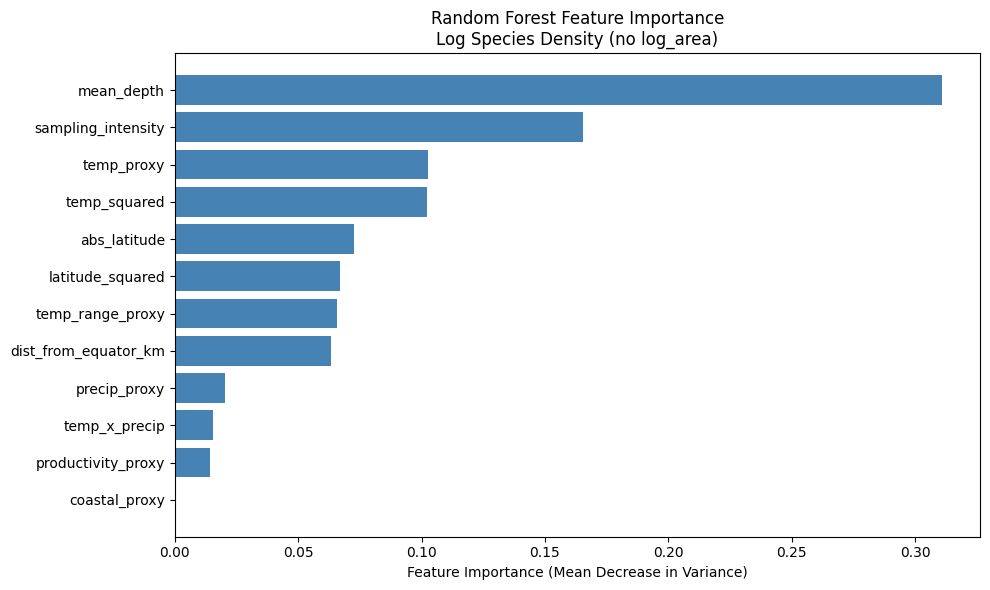

In [24]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
 
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh([features_density[i] for i in indices[::-1]],
         importances[indices[::-1]],
         color='steelblue')
ax.set_xlabel('Feature Importance (Mean Decrease in Variance)')
ax.set_title('Random Forest Feature Importance\nLog Species Density (no log_area)')
plt.tight_layout()
plt.savefig('feature_importance_main.png', dpi=150, bbox_inches='tight')
plt.show()


# Now use only ecological variables

In [25]:
rf_ns = RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=0)
rf_ns.fit(X_train_ns, y_train_ns)
y_pred_ns = rf_ns.predict(X_test_ns)
 
rmse_ns = np.sqrt(mean_squared_error(y_test_ns, y_pred_ns))
r2_ns = r2_score(y_test_ns, y_pred_ns)
 
print("Robustness Check — No sampling_intensity")
print(f"\n{'Model':<35} {'RMSE':>8} {'R²':>8}")
print("-" * 53)
print(f"{'Full model (with sampling_intensity)':<35} {rmse_rf:>8.3f} {r2_rf:>8.3f}")
print(f"{'Ecological model (no sampling)':<35} {rmse_ns:>8.3f} {r2_ns:>8.3f}")

Robustness Check — No sampling_intensity

Model                                   RMSE       R²
-----------------------------------------------------
Full model (with sampling_intensity)    0.755    0.598
Ecological model (no sampling)         0.786    0.564


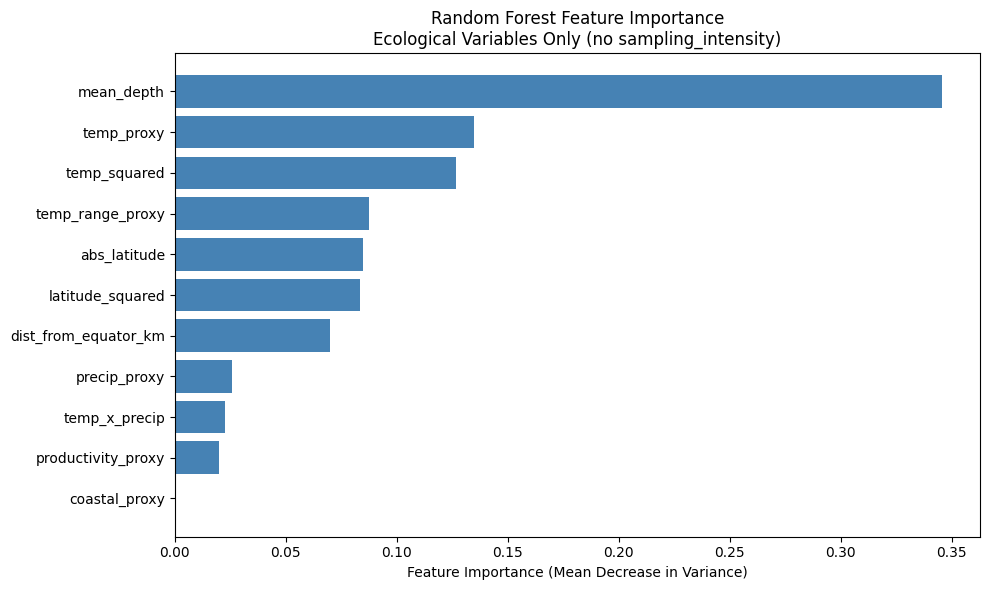

In [26]:
importances_ns = rf_ns.feature_importances_
indices_ns = np.argsort(importances_ns)[::-1]
 
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh([features_no_sampling[i] for i in indices_ns[::-1]],
         importances_ns[indices_ns[::-1]],
         color='steelblue')
ax.set_xlabel('Feature Importance (Mean Decrease in Variance)')
ax.set_title('Random Forest Feature Importance\nEcological Variables Only (no sampling_intensity)')
plt.tight_layout()
plt.savefig('feature_importance_ecological.png', dpi=150, bbox_inches='tight')
plt.show()
 


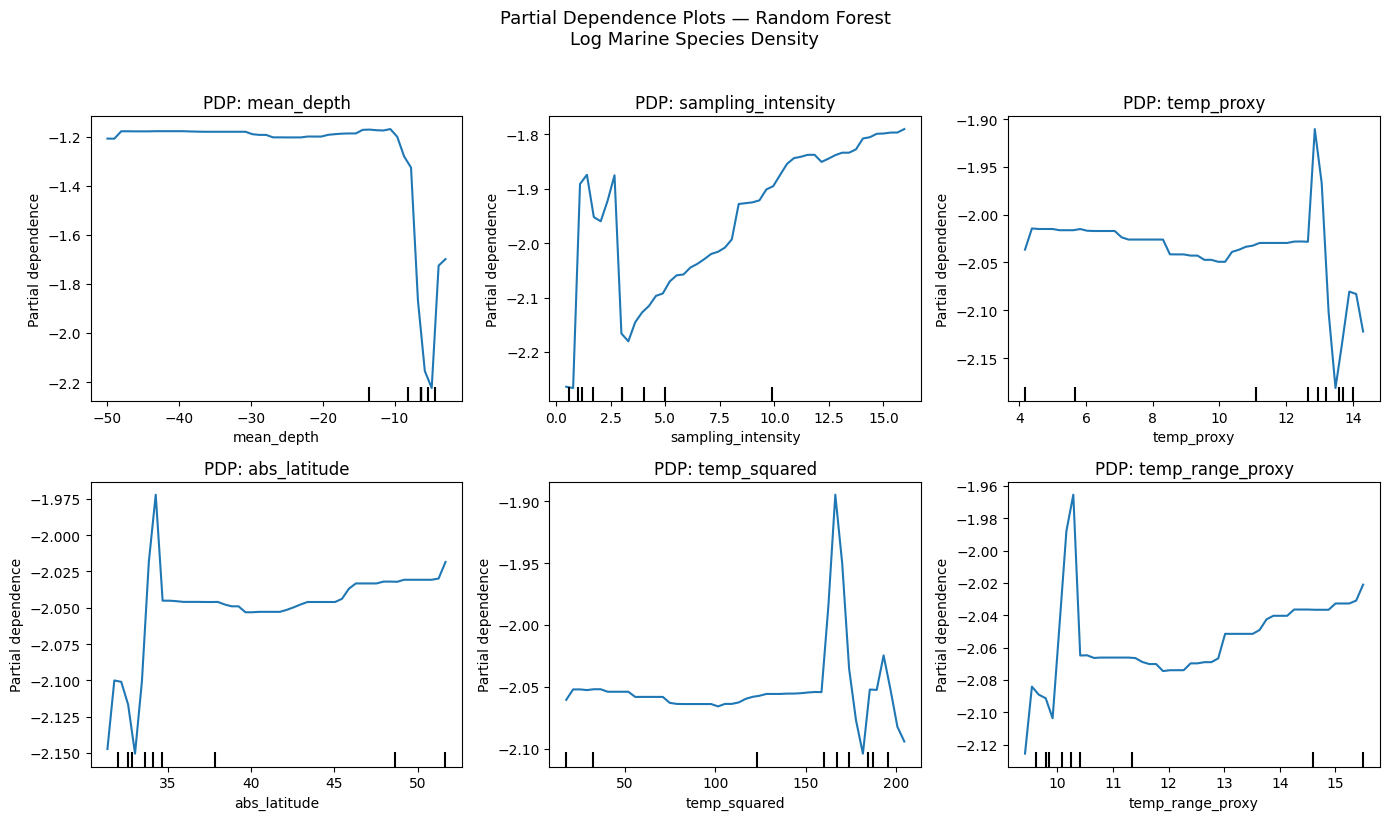

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
 
features_to_plot = ['mean_depth', 'sampling_intensity', 'temp_proxy',
                    'abs_latitude', 'temp_squared', 'temp_range_proxy']
 
for i, feat_name in enumerate(features_to_plot):
    ax = axes[i // 3][i % 3]
    PartialDependenceDisplay.from_estimator(
        rf, X_train, [feat_name],
        feature_names=features_density,
        ax=ax, grid_resolution=50
    )
    ax.set_title(f'PDP: {feat_name}')
    ax.set_ylabel('Log Species Density')
 
plt.suptitle('Partial Dependence Plots — Random Forest\nLog Marine Species Density',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('pdp_plots.png', dpi=150, bbox_inches='tight')
plt.show()


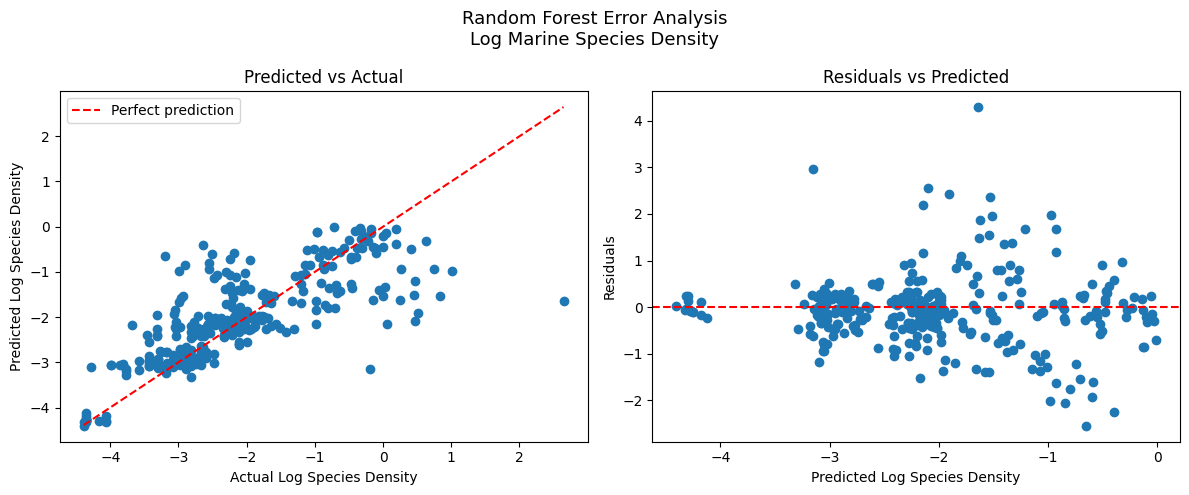

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
# Predicted vs actual
axes[0].scatter(y_test, y_pred_rf)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Log Species Density')
axes[0].set_ylabel('Predicted Log Species Density')
axes[0].set_title('Predicted vs Actual')
axes[0].legend()
 
# Residuals vs predicted
residuals = y_test - y_pred_rf
axes[1].scatter(y_pred_rf, residuals)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted Log Species Density')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals vs Predicted')
 
plt.suptitle('Random Forest Error Analysis\nLog Marine Species Density', fontsize=13)
plt.tight_layout()
plt.savefig('residuals.png', dpi=150, bbox_inches='tight')
plt.show()


### Species Richness Models original target


In [29]:
# Features including log_area for species richness prediction
features_richness = [
    'mean_depth', 'abs_latitude', 'dist_from_equator_km',
    'temp_proxy', 'temp_range_proxy', 'precip_proxy',
    'log_area', 'sampling_intensity', 'coastal_proxy',
    'temp_squared', 'temp_x_precip', 'latitude_squared',
    'productivity_proxy'
]

X_rich = md[features_richness].to_numpy()
y_rich = md['species_richness'].to_numpy()

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_rich, y_rich, test_size=0.2, random_state=0)

rf_rich = RandomForestRegressor(n_estimators=100, max_depth=10, 
                                min_samples_leaf=5, random_state=0)
rf_rich.fit(X_train_r, y_train_r)
y_pred_rich = rf_rich.predict(X_test_r)

rmse_rich = np.sqrt(mean_squared_error(y_test_r, y_pred_rich))
r2_rich = r2_score(y_test_r, y_pred_rich)

print("Target: Raw Species Richness")
print(f"  RMSE: {rmse_rich:.3f}")
print(f"  R²:   {r2_rich:.3f}")

Target: Raw Species Richness
  RMSE: 18.048
  R²:   0.687


# remove log area???? because its not a environmental predictor ie. doesnt help our outcome  ?

In [30]:
# Raw richness WITHOUT log_area — fair comparison
X_rich_no_logarea = md[features_density].to_numpy()  # same 12 features as log density

X_train_r2, X_test_r2, y_train_r2, y_test_r2 = train_test_split(
    X_rich_no_logarea, y_rich, test_size=0.2, random_state=0
)

rf_rich2 = RandomForestRegressor(n_estimators=100, max_depth=10,
                                 min_samples_leaf=5, random_state=0)
rf_rich2.fit(X_train_r2, y_train_r2)
y_pred_rich2 = rf_rich2.predict(X_test_r2)

r2_rich2 = r2_score(y_test_r2, y_pred_rich2)
print(f"Raw richness WITH log_area:    R² = {r2_rich:.3f}")
print(f"Raw richness WITHOUT log_area: R² = {r2_rich2:.3f}")
print(f"Log density WITHOUT log_area:  R² = {r2_rf:.3f}")

Raw richness WITH log_area:    R² = 0.687
Raw richness WITHOUT log_area: R² = 0.529
Log density WITHOUT log_area:  R² = 0.598


In [31]:
# 10-fold CV comparison across all three target variations
kf = KFold(n_splits=10, shuffle=True, random_state=0)

# Raw richness with log_area
cv_r2_rich_with = cross_val_score(rf_rich, X_rich, y_rich, cv=kf, scoring='r2')

# Raw richness without log_area
cv_r2_rich_without = cross_val_score(rf_rich2, X_rich_no_logarea, y_rich, cv=kf, scoring='r2')

# Log density without log_area
cv_r2_density = cross_val_score(rf, X_main, y_density, cv=kf, scoring='r2')

print("10-Fold CV R² Comparison")
print(f"\n{'Target':<35} {'Single Split R²':>16} {'CV Mean R²':>12} {'CV Std':>8}")
print("-" * 73)
print(f"{'Raw richness WITH log_area':<35} {r2_rich:>16.3f} {cv_r2_rich_with.mean():>12.3f} {cv_r2_rich_with.std():>8.3f}")
print(f"{'Raw richness WITHOUT log_area':<35} {r2_rich2:>16.3f} {cv_r2_rich_without.mean():>12.3f} {cv_r2_rich_without.std():>8.3f}")
print(f"{'Log density WITHOUT log_area':<35} {r2_rf:>16.3f} {cv_r2_density.mean():>12.3f} {cv_r2_density.std():>8.3f}")

10-Fold CV R² Comparison

Target                               Single Split R²   CV Mean R²   CV Std
-------------------------------------------------------------------------
Raw richness WITH log_area                     0.687        0.686    0.118
Raw richness WITHOUT log_area                  0.529        0.553    0.128
Log density WITHOUT log_area                   0.598        0.661    0.056


In [32]:
def print_tree(node, feature_names, depth=0, max_depth=3):
    indent = "    " * depth
    if 'value' in node:
        print(f"{indent}→ predict: {node['value']:.3f}")
        return
    if depth >= max_depth:
        print(f"{indent}...")
        return
    feature_name = feature_names[node['feature']]
    print(f"{indent}if {feature_name} <= {node['threshold']:.3f}:")
    print_tree(node['left'], feature_names, depth + 1, max_depth)
    print(f"{indent}else:")
    print_tree(node['right'], feature_names, depth + 1, max_depth)
 
print("From-Scratch Decision Tree Structure (top 3 levels):")
print("=" * 50)
print_tree(tree_scratch, features_density, max_depth=3)


From-Scratch Decision Tree Structure (top 3 levels):
if abs_latitude <= 33.626:
    if mean_depth <= -6.420:
        if abs_latitude <= 32.750:
            ...
        else:
            ...
    else:
        if abs_latitude <= 31.539:
            ...
        else:
            ...
else:
    if mean_depth <= -61.627:
        if mean_depth <= -97.475:
            ...
        else:
            ...
    else:
        if abs_latitude <= 34.472:
            ...
        else:
            ...


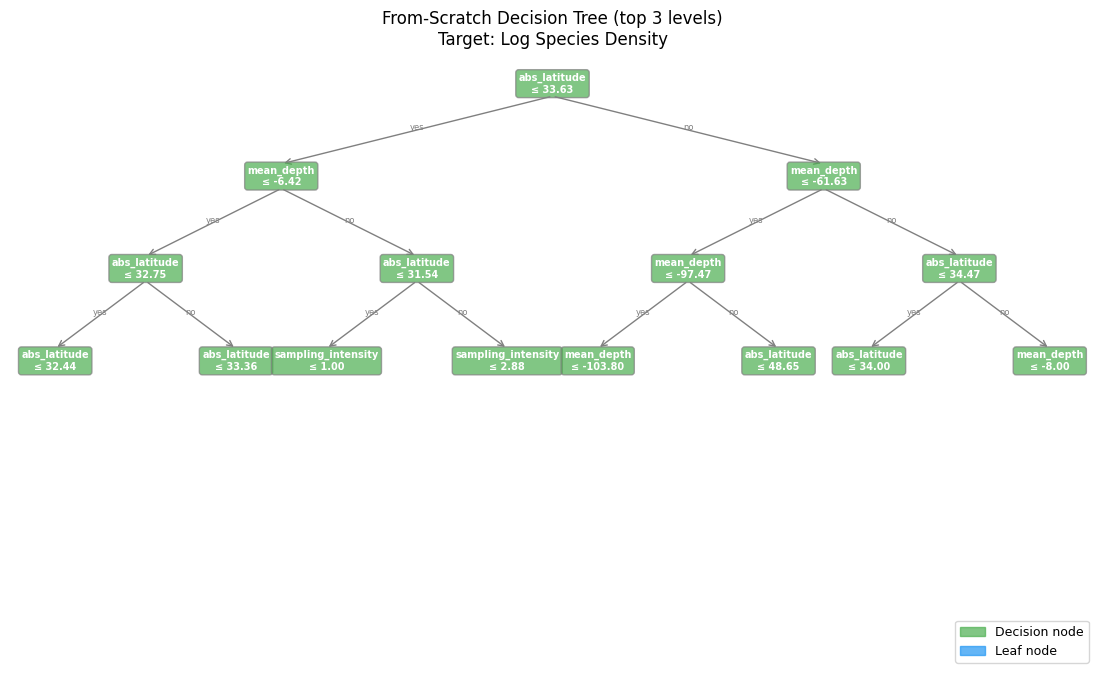

In [33]:
def plot_tree_dict(node, feature_names, ax, x=0.5, y=0.95,
                   dx=0.25, dy=0.15, depth=0, max_depth=3):
    if depth > max_depth:
        return
    if 'value' in node:
        text = f"predict\n{node['value']:.2f}"
        color = '#2196F3'
    else:
        feature_name = feature_names[node['feature']]
        text = f"{feature_name}\n≤ {node['threshold']:.2f}"
        color = '#4CAF50'
    ax.text(x, y, text, ha='center', va='center',
            fontsize=7,
            bbox=dict(boxstyle='round,pad=0.3',
                     facecolor=color, alpha=0.7, edgecolor='gray'),
            color='white', fontweight='bold')
    if 'value' in node or depth >= max_depth:
        return
    x_left = x - dx / (depth + 1)
    y_left = y - dy
    ax.annotate('', xy=(x_left, y_left + 0.02), xytext=(x, y - 0.02),
                arrowprops=dict(arrowstyle='->', color='gray'))
    ax.text((x + x_left) / 2, (y + y_left) / 2, 'yes', fontsize=6, color='gray', ha='center')
    plot_tree_dict(node['left'], feature_names, ax, x_left, y_left, dx, dy, depth + 1, max_depth)
    x_right = x + dx / (depth + 1)
    y_right = y - dy
    ax.annotate('', xy=(x_right, y_right + 0.02), xytext=(x, y - 0.02),
                arrowprops=dict(arrowstyle='->', color='gray'))
    ax.text((x + x_right) / 2, (y + y_right) / 2, 'no', fontsize=6, color='gray', ha='center')
    plot_tree_dict(node['right'], feature_names, ax, x_right, y_right, dx, dy, depth + 1, max_depth)
 
fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
plot_tree_dict(tree_scratch, features_density, ax, max_depth=3)
green = mpatches.Patch(color='#4CAF50', alpha=0.7, label='Decision node')
blue = mpatches.Patch(color='#2196F3', alpha=0.7, label='Leaf node')
ax.legend(handles=[green, blue], loc='lower right', fontsize=9)
plt.title('From-Scratch Decision Tree (top 3 levels)\nTarget: Log Species Density', fontsize=12)
plt.savefig('tree_visual.png', dpi=150, bbox_inches='tight')
plt.show()
 


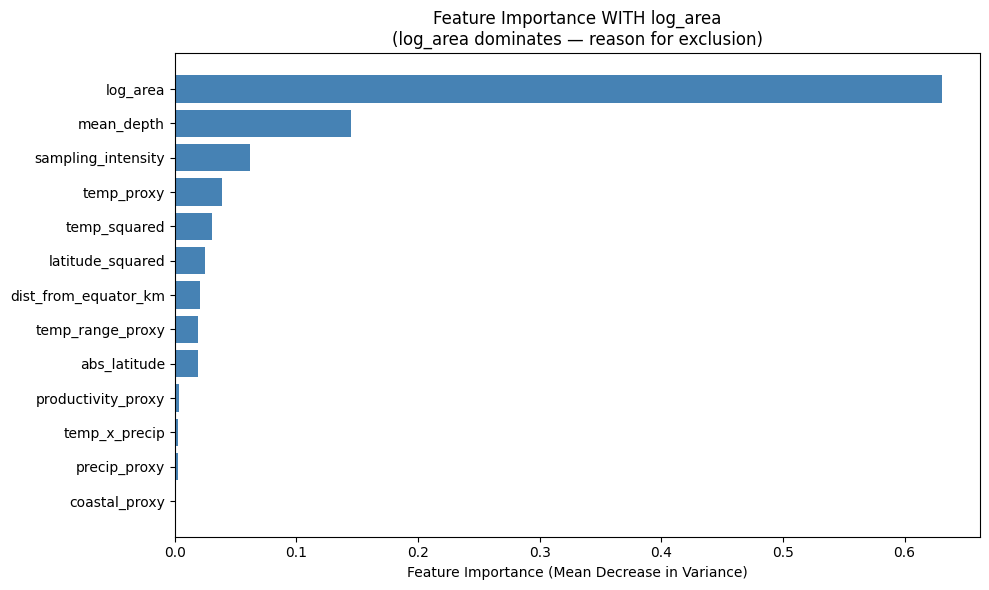

In [34]:
# Build feature matrix WITH log_area for comparison
features_with_logarea = features_density + ['log_area']
X_logarea = md[features_with_logarea].to_numpy()
X_train_la, X_test_la, y_train_la, y_test_la = train_test_split(
    X_logarea, y_density, test_size=0.2, random_state=0
)
rf_la = RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=0)
rf_la.fit(X_train_la, y_train_la)
 
importances_la = rf_la.feature_importances_
indices_la = np.argsort(importances_la)[::-1]
 
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh([features_with_logarea[i] for i in indices_la[::-1]],
         importances_la[indices_la[::-1]],
         color='steelblue')
ax.set_xlabel('Feature Importance (Mean Decrease in Variance)')
ax.set_title('Feature Importance WITH log_area\n(log_area dominates — reason for exclusion)')
plt.tight_layout()
plt.savefig('feature_importance_with_logarea.png', dpi=150, bbox_inches='tight')
plt.show()
